# Quantum Entanglement

In [1]:
from qiskit import __version__

print(__version__)

2.3.0


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

## Quantum Teleportation

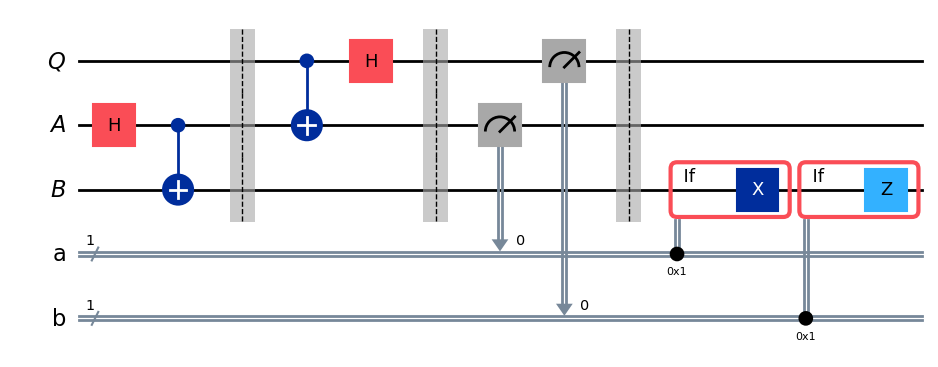

In [3]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw(output="mpl"))

The `barrier` function creates a visual separation making the circuit diagram more readable, and it also prevents Qiskit from performing various simplifications and optimizations across the barrier during compilation when circuits are run on real hardware.
The `if_test` function applies an operation conditionally depending on a classical bit or register.

The circuit first initializes $(\mathsf{A},\mathsf{B})$ to be in a $\vert \phi^+\rangle$ state (which is not part of the protocol itself), followed by Alice's operations, then her measurements, and finally Bob's operations.
To test that the protocol works correctly, we'll apply a randomly generated single-qubit gate to the initialized $\vert 0\rangle$ state of $\mathsf{Q}$ to obtain a random quantum state vector to be teleported. By applying the inverse (as in, the conjugate transpose) of that gate to $\mathsf{B}$ after the protocol is run, we can verify that the state was teleported by measuring to see that it has returned to the $\vert 0\rangle$ state.

First we'll randomly choose a unitary qubit gate.



In [4]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

Now we'll create a new testing circuit that first applies our random gate to $\mathsf{Q},$ then runs the teleportation circuit, and finally applies the inverse of our random gate to the qubit $\mathsf{B}$ and measures.
The outcome should be $0$ with certainty.



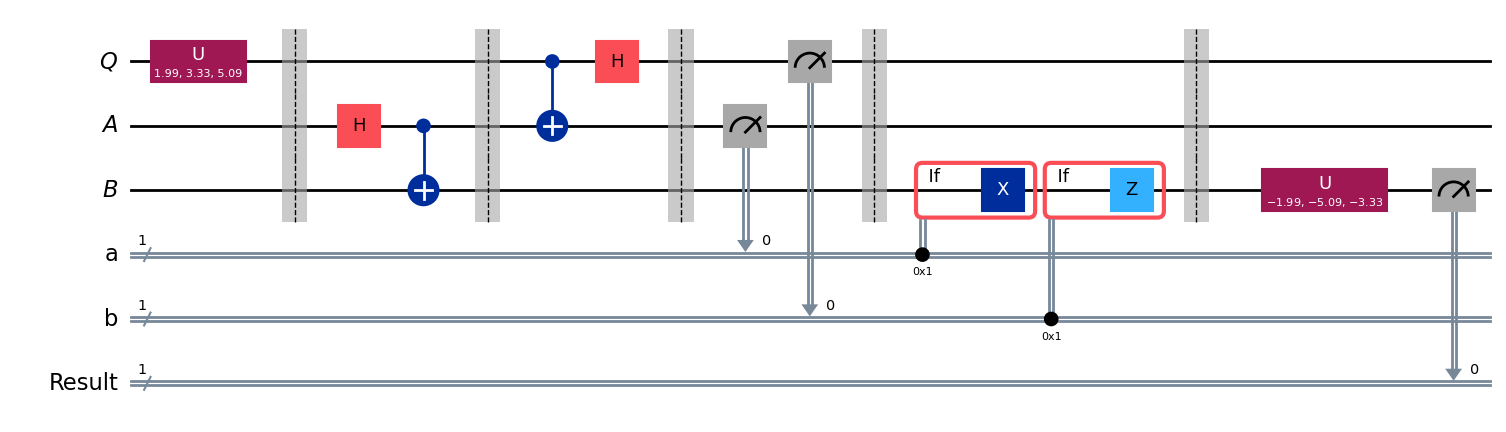

In [5]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Start with the randomly selected gate on Q

test.append(random_gate, qubit)
test.barrier()

# Append the entire teleportation protocol from above.

test = test.compose(protocol)
test.barrier()

# Finally, apply the inverse of the random unitary to B and measure.

test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw(output="mpl"))

Finally, let's run the Aer simulator on this circuit and plot a histogram of the outputs.
We'll see the statistics for all three classical bits:
the bottom/leftmost bit should always be $0,$ indicating that the qubit $\mathsf{Q}$ was successfully teleported into $\mathsf{B},$ while the other two bits should be roughly uniform.



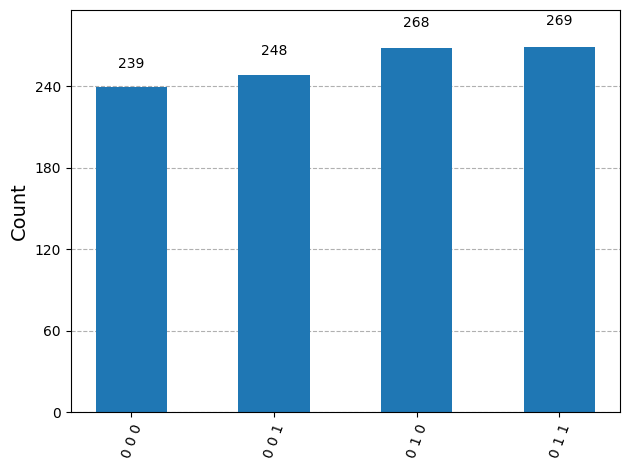

In [6]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

We can also filter the statistics to focus solely on the test result qubit if we wish, like this:



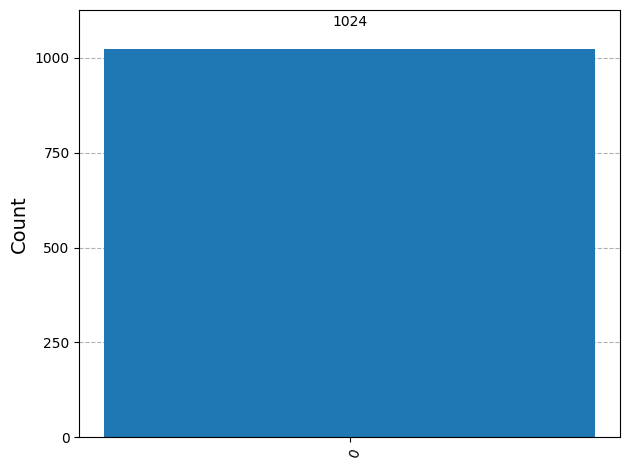

In [7]:
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

## Superdense coding

Superdense coding is a protocol that, in some sense, achieves a complementary aim to teleportation.
Rather than allowing for the transmission of one qubit using two classical bits of communication (at the cost of one e-bit of entanglement), it allows for the transmission of two classical bits using one qubit of quantum communication (again, at the cost of one e-bit of entanglement).

In greater detail, we have a sender (Alice) and a receiver (Bob) that share one e-bit of entanglement.
According to the conventions in place for the lesson, this means that Alice holds a qubit $\mathsf{A},$ Bob holds a qubit $\mathsf{B},$ and together the pair $(\mathsf{A},\mathsf{B})$ is in the state $\vert\phi^+\rangle.$
Alice wishes to transmit two classical bits to Bob, which we'll denote by $c$ and $d,$ and she will accomplish this by sending him one qubit.


### Protocol

The following quantum circuit diagram describes the superdense coding protocol:

![Superdense coding circuit](https://quantum.cloud.ibm.com/learning/images/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation/superdense-coding.avif)

In words, here is what Alice does:

1. If $d=1,$ Alice performs a $Z$ gate on her qubit $\mathsf{A}$ (and if $d=0$ she does not).

2. If $c=1,$ Alice performs an $X$ gate on her qubit $\mathsf{A}$ (and if $c=0$ she does not).

Alice then sends her qubit $\mathsf{A}$ to Bob.

What Bob does when he receives the qubit $\mathsf{A}$ is to first perform a controlled-NOT gate, with $\mathsf{A}$ being the control and $\mathsf{B}$ being the target, and then he applies a Hadamard gate to $\mathsf{A}.$
He then measures $\mathsf{B}$ to obtain $c$ and $\mathsf{A}$ to obtain $d,$ with standard basis measurements in both cases.

### Analysis

The idea behind this protocol is simple:
Alice effectively chooses which Bell state she would like to be sharing with Bob,
she sends Bob her qubit, and Bob measures to determine which Bell state Alice chose.

That is, they initially share $\vert\phi^+\rangle,$ and depending upon the bits $c$ and $d,$ Alice either leaves this state alone or shifts it to one of the other Bell states by applying $\mathbb{I},$ $X,$ $Z,$ or $XZ$ to her qubit
$\mathsf{A}.$

$$
\begin{aligned}
(\mathbb{I} \otimes \mathbb{I}) \vert \phi^+ \rangle & = \vert \phi^+\rangle \\
(\mathbb{I} \otimes Z) \vert \phi^+ \rangle & = \vert \phi^-\rangle \\
(\mathbb{I} \otimes X) \vert \phi^+ \rangle & = \vert \psi^+\rangle \\
(\mathbb{I} \otimes XZ) \vert \phi^+ \rangle & = \vert \psi^-\rangle
\end{aligned}
$$

Bob's actions have the following effects on the four Bell states:

$$
\begin{aligned}
\vert \phi^+\rangle & \mapsto \vert 00\rangle\\
\vert \phi^-\rangle & \mapsto \vert 01\rangle\\
\vert \psi^+\rangle & \mapsto \vert 10\rangle\\
\vert \psi^-\rangle & \mapsto -\vert 11\rangle\\
\end{aligned}
$$

This can be checked directly, by computing the results of Bob's operations on these states one at a time.

So, when Bob performs his measurements, he is able to determine which Bell state Alice chose.
To verify that the protocol works correctly is a matter of checking each case:

* If $cd = 00,$ then the state of $(\mathsf{B},\mathsf{A})$ when Bob receives $\mathsf{A}$ is $\vert \phi^+\rangle.$ He transforms this state into $\vert 00\rangle$ and obtains $cd = 00.$

* If $cd = 01,$ then the state of $(\mathsf{B},\mathsf{A})$ when Bob receives $\mathsf{A}$ is $\vert \phi^-\rangle.$ He transforms this state into $\vert 01\rangle$ and obtains $cd = 01.$

* If $cd = 10,$ then the state of $(\mathsf{B},\mathsf{A})$ when Bob receives $\mathsf{A}$ is $\vert \psi^+\rangle.$ He transforms this state into $\vert 10\rangle$ and obtains $cd = 10.$

* If $cd = 11,$ then the state of $(\mathsf{B},\mathsf{A})$ when Bob receives $\mathsf{A}$ is $\vert \psi^-\rangle.$ He transforms this state into $-\vert 11\rangle$ and obtains $cd = 11.$ (The negative-one phase factor has no effect here.)



### Superdense coding implementation

Here is a simple implementation of superdense coding where we specify the circuit itself depending on the bits to be transmitted. First we'll choose two bits to be transmitted. (Later we'll choose them randomly, but for now we'll just make an arbitrary choice.)



In [8]:
c = "1"
d = "0"

Now we'll build the circuit accordingly. Here we'll allow Qiskit to use the default names for the qubits: $\mathsf{q}_0$ for the top qubit and $\mathsf{q}_1$ for the bottom one.



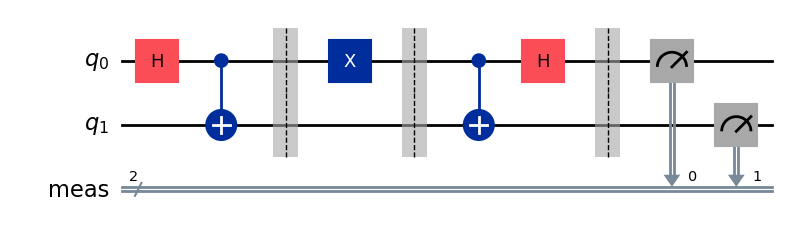

In [9]:
protocol = QuantumCircuit(2)

# Prepare ebit used for superdense coding
protocol.h(0)
protocol.cx(0, 1)
protocol.barrier()

# Alice's operations
if d == "1":
    protocol.z(0)
if c == "1":
    protocol.x(0)
protocol.barrier()

# Bob's actions
protocol.cx(0, 1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw(output="mpl"))

Not much is new here, except the `measure_all` function, which measures all of the qubits and puts the results into a single classical register (and therefore having two bits in this case).

Running the Aer simulator produces the expected output.



Measured 10 with frequency 1024


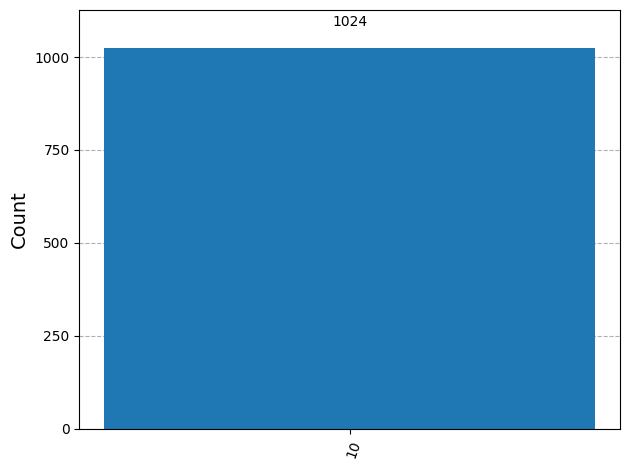

In [10]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

Now let's use an additional qubit as a random bit generator — essentially to flip fair coins. We'll use it to randomly choose $c$ and $d,$ and then run the superdense coding protocol.



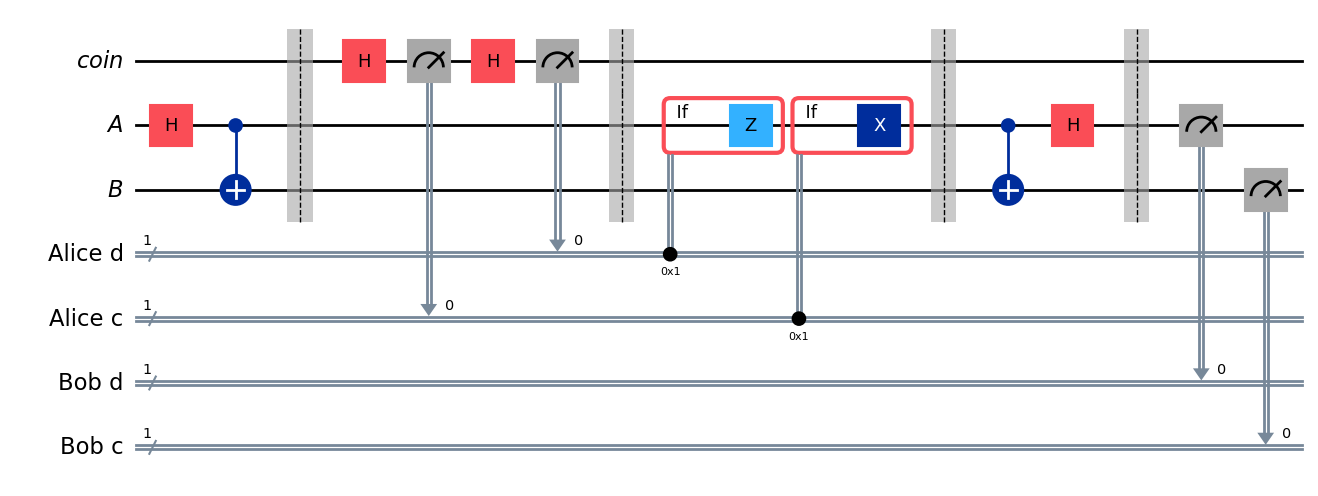

In [11]:
rbg = QuantumRegister(1, "coin")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

# Initialize the ebit
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# Use the 'coin' qubit twice to generate Alice's bits c and d.
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

# Now the protocol runs, starting with Alice's actions, which depend
# on her bits.
with test.if_test((Alice_d, 1), label="Z"):
    test.z(ebit0)
with test.if_test((Alice_c, 1), label="X"):
    test.x(ebit0)
test.barrier()

# Bob's actions
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "Bob c")
Bob_d = ClassicalRegister(1, "Bob d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw(output="mpl"))

Running the Aer simulator shows the results: Alice and Bob's classical bits always agree.



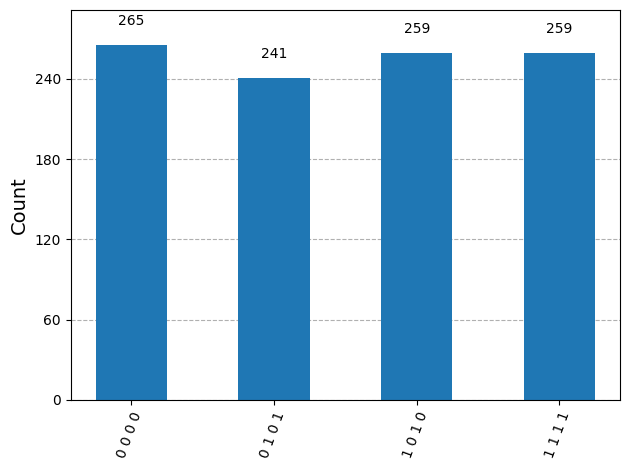

In [12]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

## The CHSH game

### CHSH game description

![Nonlocal game](https://quantum.cloud.ibm.com/learning/images/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation/nonlocal-game.avif)

Here is the precise description of the CHSH game, where (as above) $x$ is Alice's question, $y$ is Bob's question, $a$ is Alice's answer, and $b$ is Bob's answer:

* The questions and answers are all bits: $x,y,a,b\in\{0,1\}.$

* The referee chooses the questions $(x,y)$ *uniformly at random*. That is, each of the four possibilities, $(0,0),$ $(0,1),$ $(1,0),$ and $(1,1),$ is selected with probability $1/4.$

* The answers $(a,b)$ *win* for the questions $(x,y)$ if $a\oplus b = x\wedge y$ and *lose* otherwise. The following table expresses this rule by listing the winning and losing conditions on the answers $(a,b)$ for each pair of questions $(x,y).$

$$
\begin{array}{ccc}
(x,y) & \text{win} & \text{lose} \\[1mm]\hline
\rule{0mm}{4mm}(0,0) & a = b & a \neq b \\[1mm]
(0,1) & a = b & a \neq b \\[1mm]
(1,0) & a = b & a \neq b \\[1mm]
(1,1) & a \neq b & a = b
\end{array}
$$


### CHSH game strategy

![Nonlocal game with entanglement](https://quantum.cloud.ibm.com/learning/images/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation/nonlocal-game-entanglement.avif)

#### Required vectors and matrices

The first thing we need to do is to define a qubit state vector $\vert \psi_{\theta}\rangle,$ for each real number
$\theta$ (which we'll think of as an angle measured in radians) as follows.

$$
\vert\psi_{\theta}\rangle = \cos(\theta)\vert 0\rangle + \sin(\theta) \vert 1\rangle
$$

Here are some simple examples:

$$
\begin{aligned}
  \vert\psi_{0}\rangle & = \vert 0\rangle \\
  \vert\psi_{\pi/2}\rangle & = \vert 1\rangle \\
  \vert\psi_{\pi/4}\rangle & = \vert + \rangle \\
  \vert\psi_{-\pi/4}\rangle & = \vert - \rangle
\end{aligned}
$$

We also have the following examples, which arise in the analysis below:

$$
\begin{aligned}
  \vert\psi_{-\pi/8}\rangle & = \frac{\sqrt{2 + \sqrt{2}}}{2}\vert 0\rangle -\frac{\sqrt{2 - \sqrt{2}}}{2}\vert 1\rangle \\[1mm]
  \vert\psi_{\pi/8}\rangle & = \frac{\sqrt{2 + \sqrt{2}}}{2}\vert 0\rangle + \frac{\sqrt{2 - \sqrt{2}}}{2}\vert 1\rangle \\[1mm]
  \vert\psi_{3\pi/8}\rangle & = \frac{\sqrt{2 - \sqrt{2}}}{2}\vert 0\rangle + \frac{\sqrt{2 + \sqrt{2}}}{2}\vert 1\rangle \\[1mm]
  \vert\psi_{5\pi/8}\rangle & = -\frac{\sqrt{2 - \sqrt{2}}}{2}\vert 0\rangle + \frac{\sqrt{2 + \sqrt{2}}}{2}\vert 1\rangle
\end{aligned}
$$

Looking at the general form, we see that the inner product between any two of these vectors has this formula:

$$
\langle \psi_{\alpha} \vert \psi_{\beta} \rangle
= \cos(\alpha)\cos(\beta) + \sin(\alpha)\sin(\beta)
= \cos(\alpha-\beta).
\tag{3}
$$

In detail, there are only real number entries in these vectors, so there are no complex conjugates to worry about:
the inner product is the product of the cosines plus the product of the sines.
Using one of the *angle addition formulas* from trigonometry leads to the simplification above.
This formula reveals the geometric interpretation of the inner product between real unit vectors as the cosine of the angle between them.

If we compute the inner product of the *tensor product* of any two of these vectors with the $\vert \phi^+\rangle$ state, we obtain a similar expression, except that it has a $\sqrt{2}$ in the denominator:

$$
\langle \psi_{\alpha} \otimes \psi_{\beta} \vert \phi^+ \rangle
= \frac{\cos(\alpha)\cos(\beta) + \sin(\alpha)\sin(\beta)}{\sqrt{2}}
= \frac{\cos(\alpha-\beta)}{\sqrt{2}}.
\tag{4}
$$

Our interest in this particular inner product will become clear shortly, but for now we're simply observing this as a formula.

Next, define a unitary matrix $U_{\theta}$ for each angle $\theta$ as follows.

$$
U_{\theta} = \vert 0 \rangle \langle \psi_{\theta} \vert + \vert 1\rangle\langle \psi_{\theta+\pi/2} \vert
$$

Intuitively speaking, this matrix transforms $\vert\psi_{\theta}\rangle$ into $\vert 0\rangle$ and $\vert \psi_{\theta + \pi/2}\rangle$ into $\vert 1\rangle.$
To check that this is a unitary matrix, a key observation is that the vectors $\vert\psi_{\theta}\rangle$ and $\vert\psi_{\theta + \pi/2}\rangle$ are orthogonal for every angle $\theta$:

$$
\langle \psi_{\theta} \vert \psi_{\theta + \pi/2} \rangle = \cos(\pi/2) = 0.
$$

Thus, we find that

$$
\begin{aligned}
U_{\theta} U_{\theta}^{\dagger}
& = \bigl(\vert 0 \rangle \langle \psi_{\theta} \vert + \vert 1\rangle\langle \psi_{\theta+\pi/2} \vert\bigr)
\bigl(\vert \psi_{\theta} \rangle \langle 0 \vert + \vert \psi_{\theta+\pi/2}\rangle\langle 1 \vert\bigr) \\[1mm]
& =
\vert 0 \rangle \langle \psi_{\theta} \vert \psi_{\theta} \rangle \langle 0 \vert
+ \vert 0 \rangle \langle \psi_{\theta} \vert \psi_{\theta+\pi/2} \rangle \langle 1 \vert
+ \vert 1 \rangle \langle \psi_{\theta+\pi/2} \vert \psi_{\theta} \rangle \langle 0 \vert
+ \vert 1 \rangle \langle \psi_{\theta+\pi/2} \vert \psi_{\theta+\pi/2} \rangle \langle 1 \vert \\[1mm]
& =
\vert 0 \rangle \langle 0 \vert + \vert 1 \rangle \langle 1 \vert\\[1mm]
& = \mathbb{I}.
\end{aligned}
$$

We may alternatively write this matrix explicitly as

$$
U_{\theta}
= \begin{pmatrix}
\cos(\theta) & \sin(\theta)\\[1mm]
\cos(\theta+ \pi/2) & \sin(\theta + \pi/2)
\end{pmatrix}
= \begin{pmatrix}
\cos(\theta) & \sin(\theta)\\[1mm]
-\sin(\theta) & \cos(\theta)
\end{pmatrix}.
$$

This is an example of a *rotation matrix*, and specifically it rotates two-dimensional vectors with real number entries by an angle of $-\theta$ about the origin.
If we follow a standard convention for naming and parameterizing rotations of various forms, we have
$U_{\theta} = R_y(-2\theta)$ where

$$
R_y(\theta) = \begin{pmatrix}
\cos(\theta/2) & -\sin(\theta/2)\\[1mm]
\sin(\theta/2) & \cos(\theta/2)
\end{pmatrix}.
$$



#### Strategy description

Now we can describe the quantum strategy.

* **Set-up:** Alice and Bob start the game sharing an e-bit: Alice holds a qubit $\mathsf{A},$ Bob holds a qubit $\mathsf{B},$ and together the two qubits $(\mathsf{X},\mathsf{Y})$ are in the $\vert\phi^+\rangle$ state.

* **Alice's actions:**

  * If Alice receives the question $x=0,$ she applies $U_{0}$ to her qubit $\mathsf{A}.$
  * If Alice receives the question  $x=1,$ she applies $U_{\pi/4}$ to her qubit $\mathsf{A}.$

  The operation Alice performs on $\mathsf{A}$ may alternatively be described like this:

  $$
  \begin{cases}
  U_0 & \text{if $x = 0$}\\
  U_{\pi/4} & \text{if $x = 1$}
  \end{cases}
  $$

  After Alice applies this operation, she measures $\mathsf{A}$ with a standard basis measurement and sets her answer $a$ to be the measurement outcome.

* **Bob's actions:**

  * If Bob receives the question $y=0,$ he applies $U_{\pi/8}$ to his qubit $\mathsf{B}.$
  * If Bob receives the question $y=1,$ he applies $U_{-\pi/8}$ to his qubit $\mathsf{B}.$

  Like we did for Alice, we can express Bob's operation on $\mathsf{B}$ like this:

  $$
  \begin{cases}
  U_{\pi/8} & \text{if $y = 0$}\\
  U_{-\pi/8} & \text{if $y = 1$}
  \end{cases}
  $$

  After Bob applies this operation, he measures $\mathsf{B}$ with a standard basis measurement and sets his answer $b$ to be the measurement outcome.

Here is a quantum circuit diagram that describes this strategy:

![CHSH game circuit](https://quantum.cloud.ibm.com/learning/images/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation/CHSH.avif)


#### Case-by-case analysis

* Case 1:  $(x,y) = (0,0).$

  In this case Alice performs $U_{0}$ on her qubit and Bob performs $U_{\pi/8}$ on his, so the state of the two qubits $(\mathsf{A},\mathsf{B})$ after they perform their operations is

  $$
  \begin{aligned}
  \bigl(U_0 \otimes U_{\pi/8}\bigr) \vert \phi^+\rangle
  & =
  \vert 00 \rangle \langle \psi_0 \otimes \psi_{\pi/8}\vert \phi^+\rangle
  + \vert 01 \rangle \langle \psi_0 \otimes\psi_{5\pi/8}\vert \phi^+\rangle \\
  & \qquad + \vert 10 \rangle \langle \psi_{\pi/2} \otimes \psi_{\pi/8}\vert \phi^+\rangle
  + \vert 11 \rangle \langle \psi_{\pi/2} \otimes \psi_{5\pi/8}\vert \phi^+\rangle\\[2mm]
  & = \frac{
      \cos\bigl(-\frac{\pi}{8}\bigr) \vert 00\rangle
    + \cos\bigl(-\frac{5\pi}{8}\bigr) \vert 01\rangle
    + \cos\bigl(\frac{3\pi}{8}\bigr) \vert 10\rangle
    + \cos\bigl(-\frac{\pi}{8}\bigr) \vert 11\rangle}{\sqrt{2}}.
  \end{aligned}
  $$

  The probabilities for the four possible answer pairs $(a,b)$ are therefore as follows.

  $$
  \begin{aligned}
  \operatorname{Pr}\bigl((a,b)=(0,0)\bigr) & = \frac{1}{2}\cos^2\Bigl(-\frac{\pi}{8}\Bigr) = \frac{2+\sqrt{2}}{8} \\[2mm]
  \operatorname{Pr}\bigl((a,b)=(0,1)\bigr) & = \frac{1}{2}\cos^2\Bigl(-\frac{5\pi}{8}\Bigr) = \frac{2-\sqrt{2}}{8}\\[2mm]
  \operatorname{Pr}\bigl((a,b)=(1,0)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{3\pi}{8}\Bigr) = \frac{2-\sqrt{2}}{8}\\[2mm]
  \operatorname{Pr}\bigl((a,b)=(1,1)\bigr) & = \frac{1}{2}\cos^2\Bigl(-\frac{\pi}{8}\Bigr) = \frac{2+\sqrt{2}}{8}
  \end{aligned}
  $$

  We can then obtain the probabilities that $a=b$ and $a\neq b$ by summing.

  $$
  \begin{aligned}
  \operatorname{Pr}(a = b) & = \frac{2 + \sqrt{2}}{4}\\[2mm]
  \operatorname{Pr}(a \neq b) & = \frac{2 - \sqrt{2}}{4}
  \end{aligned}
  $$

  For the question pair $(0,0),$ Alice and Bob win if $a=b,$ and therefore they win in this case with probability

  $$
  \frac{2 + \sqrt{2}}{4}.
  $$

* Case 2:  $(x,y) = (0,1).$

  In this case Alice performs $U_{0}$ on her qubit and Bob performs $U_{-\pi/8}$ on his, so the state of the two qubits $(\mathsf{A},\mathsf{B})$ after they perform their operations is

  $$
  \begin{aligned}
  \bigl(U_0 \otimes U_{-\pi/8}\bigr) \vert \phi^+\rangle
  & =
  \vert 00 \rangle \langle \psi_0 \otimes \psi_{-\pi/8}\vert \phi^+\rangle
  + \vert 01 \rangle \langle \psi_0 \otimes\psi_{3\pi/8}\vert \phi^+\rangle \\
  & \qquad + \vert 10 \rangle \langle \psi_{\pi/2} \otimes \psi_{-\pi/8}\vert \phi^+\rangle
  + \vert 11 \rangle \langle \psi_{\pi/2} \otimes \psi_{3\pi/8}\vert \phi^+\rangle\\[2mm]
  & = \frac{
      \cos\bigl(\frac{\pi}{8}\bigr) \vert 00\rangle
    + \cos\bigl(-\frac{3\pi}{8}\bigr) \vert 01\rangle
    + \cos\bigl(\frac{5\pi}{8}\bigr) \vert 10\rangle
    + \cos\bigl(\frac{\pi}{8}\bigr) \vert 11\rangle}{\sqrt{2}}.
  \end{aligned}
  $$

  The probabilities for the four possible answer pairs $(a,b)$ are therefore as follows.

  $$
  \begin{aligned}
  \operatorname{Pr}\bigl((a,b)=(0,0)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{\pi}{8}\Bigr) = \frac{2+\sqrt{2}}{8} \\[2mm]
  \operatorname{Pr}\bigl((a,b)=(0,1)\bigr) & = \frac{1}{2}\cos^2\Bigl(-\frac{3\pi}{8}\Bigr) = \frac{2-\sqrt{2}}{8}\\[2mm]
  \operatorname{Pr}\bigl((a,b)=(1,0)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{5\pi}{8}\Bigr) = \frac{2-\sqrt{2}}{8}\\[2mm]
  \operatorname{Pr}\bigl((a,b)=(1,1)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{\pi}{8}\Bigr) = \frac{2+\sqrt{2}}{8}
  \end{aligned}
  $$

  Again, we can obtain the probabilities that $a=b$ and $a\neq b$ by summing.

  $$
  \begin{aligned}
  \operatorname{Pr}(a = b) & = \frac{2 + \sqrt{2}}{4}\\[2mm]
  \operatorname{Pr}(a \neq b) & = \frac{2 - \sqrt{2}}{4}
  \end{aligned}
  $$

  For the question pair $(0,1),$ Alice and Bob win if $a=b,$ and therefore they win in this case with probability

  $$
  \frac{2 + \sqrt{2}}{4}.
  $$

* Case 3:  $(x,y) = (1,0).$

  In this case Alice performs $U_{\pi/4}$ on her qubit and Bob performs $U_{\pi/8}$ on his, so the state of the two qubits $(\mathsf{A},\mathsf{B})$ after they perform their operations is

  $$
  \begin{aligned}
  \bigl(U_{\pi/4} \otimes U_{\pi/8}\bigr) \vert \phi^+\rangle
  & =
  \vert 00 \rangle \langle \psi_{\pi/4} \otimes \psi_{\pi/8}\vert \phi^+\rangle
  + \vert 01 \rangle \langle \psi_{\pi/4} \otimes\psi_{5\pi/8}\vert \phi^+\rangle \\
  & \qquad + \vert 10 \rangle \langle \psi_{3\pi/4} \otimes \psi_{\pi/8}\vert \phi^+\rangle
  + \vert 11 \rangle \langle \psi_{3\pi/4} \otimes \psi_{5\pi/8}\vert \phi^+\rangle\\[2mm]
  & = \frac{
      \cos\bigl(\frac{\pi}{8}\bigr) \vert 00\rangle
    + \cos\bigl(-\frac{3\pi}{8}\bigr) \vert 01\rangle
    + \cos\bigl(\frac{5\pi}{8}\bigr) \vert 10\rangle
    + \cos\bigl(\frac{\pi}{8}\bigr) \vert 11\rangle}{\sqrt{2}}.
  \end{aligned}
  $$

  The probabilities for the four possible answer pairs $(a,b)$ are therefore as follows.

  $$
  \begin{aligned}
  \operatorname{Pr}\bigl((a,b)=(0,0)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{\pi}{8}\Bigr) = \frac{2+\sqrt{2}}{8} \\[2mm]
  \operatorname{Pr}\bigl((a,b)=(0,1)\bigr) & = \frac{1}{2}\cos^2\Bigl(-\frac{3\pi}{8}\Bigr) = \frac{2-\sqrt{2}}{8}\\[2mm]
  \operatorname{Pr}\bigl((a,b)=(1,0)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{5\pi}{8}\Bigr) = \frac{2-\sqrt{2}}{8}\\[2mm]
  \operatorname{Pr}\bigl((a,b)=(1,1)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{\pi}{8}\Bigr) = \frac{2+\sqrt{2}}{8}
  \end{aligned}
  $$

  We find, once again, that probabilities that $a=b$ and $a\neq b$ are as follows.

  $$
  \begin{aligned}
  \operatorname{Pr}(a = b) & = \frac{2 + \sqrt{2}}{4}\\[2mm]
  \operatorname{Pr}(a \neq b) & = \frac{2 - \sqrt{2}}{4}
  \end{aligned}
  $$

  For the question pair $(1,0),$ Alice and Bob win if $a=b,$ so they win in this case with probability

  $$
  \frac{2 + \sqrt{2}}{4}.
  $$

* Case 4:  $(x,y) = (1,1).$

  The last case is a little bit different, as we might expect because the winning condition is different in this case. When $x$ and $y$ are both $1,$ Alice and Bob win when $a$ and $b$ are *different*. In this case Alice performs $U_{\pi/4}$ on her qubit and Bob performs $U_{-\pi/8}$ on his, so the state of the two qubits $(\mathsf{A},\mathsf{B})$ after they perform their operations is

  $$
  \begin{aligned}
  \bigl(U_{\pi/4} \otimes U_{-\pi/8}\bigr) \vert \phi^+\rangle
  & =
  \vert 00 \rangle \langle \psi_{\pi/4} \otimes \psi_{-\pi/8}\vert \phi^+\rangle
  + \vert 01 \rangle \langle \psi_{\pi/4} \otimes\psi_{3\pi/8}\vert \phi^+\rangle \\
  & \qquad + \vert 10 \rangle \langle \psi_{3\pi/4} \otimes \psi_{-\pi/8}\vert \phi^+\rangle
  + \vert 11 \rangle \langle \psi_{3\pi/4} \otimes \psi_{3\pi/8}\vert \phi^+\rangle\\[2mm]
  & = \frac{
      \cos\bigl(\frac{3\pi}{8}\bigr) \vert 00\rangle
    + \cos\bigl(-\frac{\pi}{8}\bigr) \vert 01\rangle
    + \cos\bigl(\frac{7\pi}{8}\bigr) \vert 10\rangle
    + \cos\bigl(\frac{3\pi}{8}\bigr) \vert 11\rangle}{\sqrt{2}}.
  \end{aligned}
  $$

  The probabilities for the four possible answer pairs $(a,b)$ are therefore as follows.

  $$
  \begin{aligned}
  \operatorname{Pr}\bigl((a,b)=(0,0)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{3\pi}{8}\Bigr) = \frac{2-\sqrt{2}}{8} \\[2mm]
  \operatorname{Pr}\bigl((a,b)=(0,1)\bigr) & = \frac{1}{2}\cos^2\Bigl(-\frac{\pi}{8}\Bigr) = \frac{2+\sqrt{2}}{8}\\[2mm]
  \operatorname{Pr}\bigl((a,b)=(1,0)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{7\pi}{8}\Bigr) = \frac{2+\sqrt{2}}{8}\\[2mm]
  \operatorname{Pr}\bigl((a,b)=(1,1)\bigr) & = \frac{1}{2}\cos^2\Bigl(\frac{3\pi}{8}\Bigr) = \frac{2-\sqrt{2}}{8}
  \end{aligned}
  $$

  The probabilities have effectively swapped places from in the three other cases.
  We obtain the probabilities that $a=b$ and $a\neq b$ by summing.

  $$
  \begin{aligned}
  \operatorname{Pr}(a = b) & = \frac{2 - \sqrt{2}}{4}\\[2mm]
  \operatorname{Pr}(a \neq b) & = \frac{2 + \sqrt{2}}{4}
  \end{aligned}
  $$

  For the question pair $(1,1),$ Alice and Bob win if $a\neq b,$ and therefore they win in this case with probability

  $$
  \frac{2 + \sqrt{2}}{4}.
  $$

They win in every case with the same probability:

$$
  \frac{2 + \sqrt{2}}{4} \approx 0.85.
$$

This is therefore the probability that they win overall.
That's significantly better than any classical strategy can do for this game; classical strategies have winning probability bounded by $3/4.$ And that makes this a very interesting example.


### Qiskit implementation

We can implement the CHSH game, together with the quantum strategy defined above, in Qiskit as follows.

First, here's the definition of the game itself, which allows an arbitrary strategy to be plugged in as an argument.



In [14]:
def chsh_game(strategy):
    # This function runs the CHSH game, using the strategy (a function
    # from two bits to two bits), returning 1 for a win and 0 for a loss.

    # Choose x and y randomly
    x, y = random.randint(0, 1), random.randint(0, 1)

    # Use the strategy to determine a and b
    a, b = strategy(x, y)

    # Decide if the strategy wins or loses
    if (a != b) == (x & y):
        return 1  # Win
    return 0  # Lose

Now we'll create a function that outputs a circuit depending on the questions for Alice and Bob. We'll let the qubits have their default names for simplicity, and we'll use the built-in $R_y(\theta)$ gate for Alice and Bob's actions.



In [15]:
def chsh_circuit(x, y):
    # This function creates a `QuantumCircuit` implementing the quantum
    # strategy described above (including the e-bit preparation).

    qc = QuantumCircuit(2, 2)

    # Prepare an e-bit
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # Alice's actions
    if x == 0:
        qc.ry(0, 0)
    else:
        qc.ry(-pi / 2, 0)
    qc.measure(0, 0)

    # Bob's actions
    if y == 0:
        qc.ry(-pi / 4, 1)
    else:
        qc.ry(pi / 4, 1)
    qc.measure(1, 1)

    return qc

Here are the four possible circuits, depending on which questions are asked.



(x,y) = (0,0)


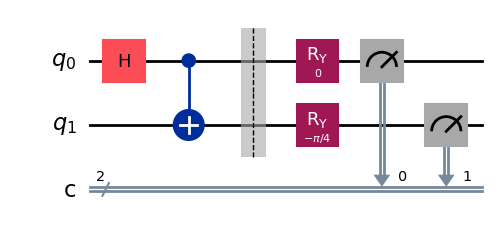

(x,y) = (0,1)


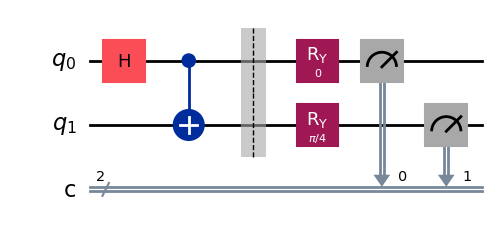

(x,y) = (1,0)


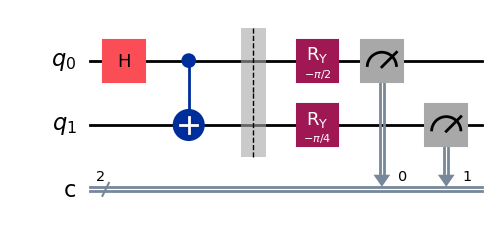

(x,y) = (1,1)


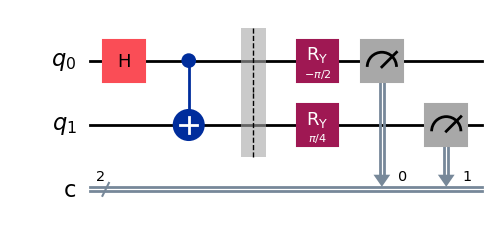

In [16]:
# Draw the four possible circuits

print("(x,y) = (0,0)")
display(chsh_circuit(0, 0).draw(output="mpl"))

print("(x,y) = (0,1)")
display(chsh_circuit(0, 1).draw(output="mpl"))

print("(x,y) = (1,0)")
display(chsh_circuit(1, 0).draw(output="mpl"))

print("(x,y) = (1,1)")
display(chsh_circuit(1, 1).draw(output="mpl"))

Now we'll create a job using the Aer simulator that runs the circuit a single time for a given input pair $(x,y).$



In [17]:
def quantum_strategy(x, y):
    # This function runs the appropriate quantum circuit defined above
    # one time and returns the measurement results

    # Setting `shots=1` to run the circuit once
    result = AerSimulator().run(chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    # Determine the output bits and return them
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b

Finally, we'll play the game 1000 times and compute the fraction that the strategy wins.



In [18]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.854


We can also define a classical strategy and see how well it works.
This is just one strategy — others can be tested by changing the code — but it is among the optimal classical strategies.



In [29]:
def classical_strategy(x, y):
    # This function implements just one example of an optimal classical
    # strategy for the CHSH game. Other classical strategies can be
    # implemented by changing the bit values assigned to a and b.

    # Alice's answer
    if x == 0:
        a = 0
    elif x == 1:
        a = 1

    # Bob's answer
    if y == 0:
        b = 1
    elif y == 1:
        b = 0

    return a, b

Again let's play the game 1000 times to see how well it works.



In [36]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(classical_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.759


Although there's randomness involved, the statistics are very unlikely to deviate too much after 1000 runs. The quantum strategy wins about 85% of the time while a classical strategy can't win more than about 75% of the time.

